# 🔍 CreditRiskAI — Day 2: Exploratory Data Analysis & Risk Cohort Insights
**Project**: Give Me Some Credit (Default Risk Analytics)  
**Author**: Ganendra Pradipa | [Portfolio](https://ganendra.space) | [LinkedIn](https://www.linkedin.com/in/ganendrapratama) | [GitHub](https://github.com/dipndeep)  
**Objective**: Uncover empirical behavioral patterns across 150,000 borrowers, quantify default rates across business cohorts, and formulate actionable credit underwriting policies.

---

## 1. 🏢 Executive Context: Bridging Data to Underwriting Policy

In credit risk modeling, algorithms should never operate in a vacuum. Underwriters and risk committees require empirical rationale:
* **Who** are the riskiest borrowers, and what behavioral signals precede serious delinquency?
* **At what thresholds** does borrower distress transition from manageable to catastrophic?
* **How** can risk policies (credit limits, pricing, collateral requirements) be tuned dynamically?

In this notebook, we dissect the sanitized dataset produced on Day 1 to extract **4 core business risk insights**.


In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure elegant visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Palette
PALETTE_PRIMARY = '#1e3a8a'    # Deep Blue
PALETTE_SECONDARY = '#0284c7'  # Sky Blue
PALETTE_ACCENT = '#ef4444'     # Crimson Red
PALETTE_SUCCESS = '#10b981'    # Emerald Green

print("Libraries imported successfully. Ready for Day 2 EDA.")


Libraries imported successfully. Ready for Day 2 EDA.


---
## 2. 📂 Loading Sanitized Training Dataset
We load `train_cleaned.csv` (150,000 rows × 16 features) generated from the Day 1 data cleaning pipeline.


In [2]:
# Load cleaned data (check both relative paths)
data_path = '../data/processed/train_cleaned.csv' if os.path.exists('../data/processed/train_cleaned.csv') else 'data/processed/train_cleaned.csv'
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Total Missing Values: {df.isna().sum().sum()}")
df.head(5)


Dataset Shape: 150,000 rows × 16 columns
Total Missing Values: 0


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,HasPastDueRecordError,RevolvingUtilizationOverLimit,MonthlyIncome_is_missing,DebtRatio_is_extreme,NumberOfDependents_is_missing
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,0,0,0,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0,0,0,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,0,0,0,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,0,0,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,0,0,0,0


---
## 3. 📊 Univariate & Feature Distribution Analysis

Let us inspect the distribution curves of core borrower attributes:
* **Age (`age`)**
* **Monthly Income (`MonthlyIncome`)**
* **Debt Ratio (`DebtRatio`)**
* **Revolving Utilization (`RevolvingUtilizationOfUnsecuredLines`)**


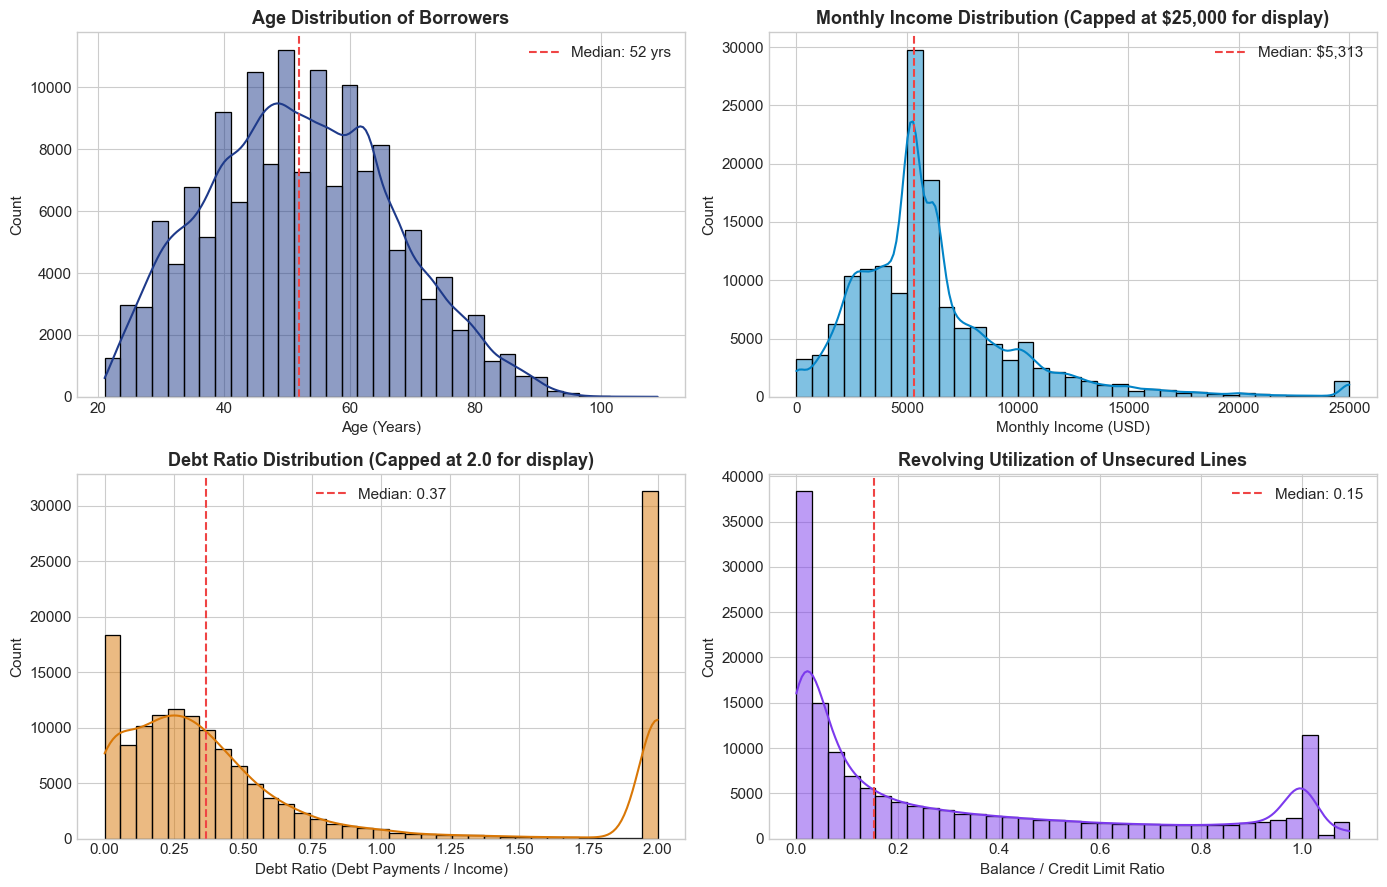

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Age
sns.histplot(df['age'], kde=True, ax=axes[0, 0], color=PALETTE_PRIMARY, bins=35)
axes[0, 0].set_title('Age Distribution of Borrowers')
axes[0, 0].set_xlabel('Age (Years)')
axes[0, 0].axvline(df['age'].median(), color=PALETTE_ACCENT, linestyle='--', label=f'Median: {df["age"].median():.0f} yrs')
axes[0, 0].legend()

# 2. Monthly Income (capped display for visualization)
income_display = df['MonthlyIncome'].clip(upper=25000)
sns.histplot(income_display, kde=True, ax=axes[0, 1], color=PALETTE_SECONDARY, bins=35)
axes[0, 1].set_title('Monthly Income Distribution (Capped at $25,000 for display)')
axes[0, 1].set_xlabel('Monthly Income (USD)')
axes[0, 1].axvline(df['MonthlyIncome'].median(), color=PALETTE_ACCENT, linestyle='--', label=f'Median: ${df["MonthlyIncome"].median():,.0f}')
axes[0, 1].legend()

# 3. Debt Ratio
debt_display = df['DebtRatio'].clip(upper=2.0)
sns.histplot(debt_display, kde=True, ax=axes[1, 0], color='#d97706', bins=35)
axes[1, 0].set_title('Debt Ratio Distribution (Capped at 2.0 for display)')
axes[1, 0].set_xlabel('Debt Ratio (Debt Payments / Income)')
axes[1, 0].axvline(df['DebtRatio'].median(), color=PALETTE_ACCENT, linestyle='--', label=f'Median: {df["DebtRatio"].median():.2f}')
axes[1, 0].legend()

# 4. Revolving Utilization
sns.histplot(df['RevolvingUtilizationOfUnsecuredLines'], kde=True, ax=axes[1, 1], color='#7c3aed', bins=35)
axes[1, 1].set_title('Revolving Utilization of Unsecured Lines')
axes[1, 1].set_xlabel('Balance / Credit Limit Ratio')
axes[1, 1].axvline(df['RevolvingUtilizationOfUnsecuredLines'].median(), color=PALETTE_ACCENT, linestyle='--', label=f'Median: {df["RevolvingUtilizationOfUnsecuredLines"].median():.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


---
## 4. 🔗 Correlation & Multicollinearity Heatmap

We examine correlations with the target variable `SeriousDlqin2yrs` to evaluate which variables exhibit the highest discriminative power.


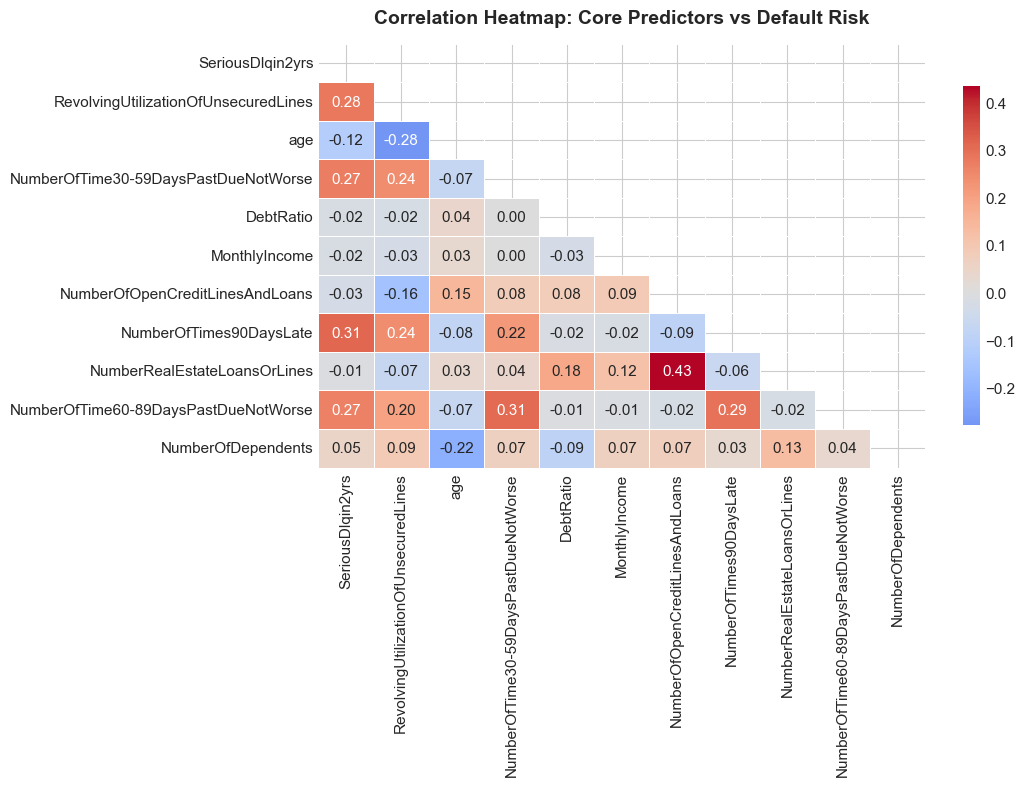

--- Correlation with SeriousDlqin2yrs (Default Risk) ---
SeriousDlqin2yrs                        1.000000
NumberOfTimes90DaysLate                 0.311713
RevolvingUtilizationOfUnsecuredLines    0.280813
NumberOfTime30-59DaysPastDueNotWorse    0.271411
NumberOfTime60-89DaysPastDueNotWorse    0.265594
NumberOfDependents                      0.046869
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.017429
MonthlyIncome                          -0.017947
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115397


In [4]:
# Compute correlation matrix for core numerical predictors
core_cols = [
    'SeriousDlqin2yrs',
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]

corr_matrix = df[core_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap: Core Predictors vs Default Risk', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Ranking correlation with target
print("--- Correlation with SeriousDlqin2yrs (Default Risk) ---")
target_corr = corr_matrix['SeriousDlqin2yrs'].sort_values(ascending=False)
print(target_corr.to_string())


---
## 5. 🎯 Deep-Dive Risk Cohort Analysis (The Core Insights)

To translate machine learning features into banking underwriting policies, we segment borrowers across 4 critical business dimensions:
1. **Age Cohorts** (<30 vs 30-44 vs 45-59 vs 60+)
2. **Revolving Credit Utilization Tiers** (<30% vs 30-70% vs 70-100% vs >100%)
3. **Mortgage Collateral Backing** (Borrowers with KPR vs Unsecured Only)
4. **Income Quartiles vs Debt Burden**


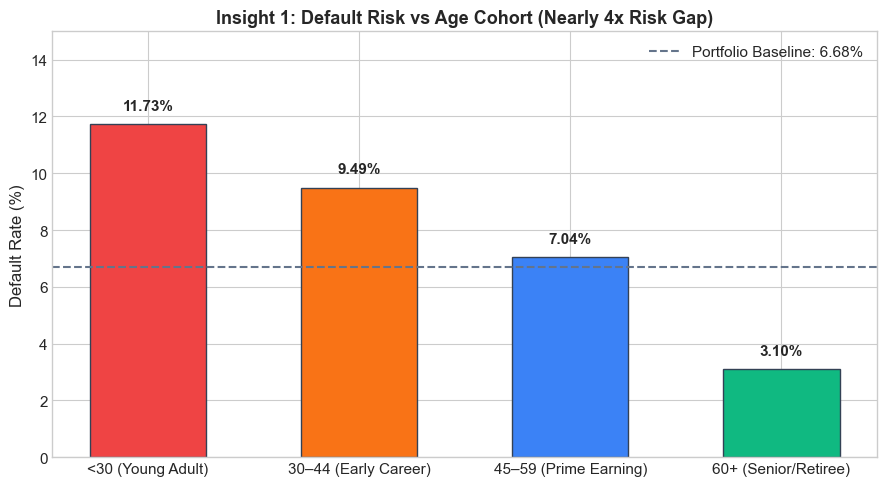

,age_group,Total_Borrowers,Defaulted_Count,Default_Rate,Default_Rate_Pct
0,<30 (Young Adult),8820,1035,0.117347,11.73
1,30–44 (Early Career),38982,3700,0.094916,9.49
2,45–59 (Prime Earning),53880,3791,0.070360,7.04
3,60+ (Senior/Retiree),48318,1500,0.031044,3.10


In [5]:
# Cohort 1: Age Brackets
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 29, 44, 59, 120],
    labels=['<30 (Young Adult)', '30–44 (Early Career)', '45–59 (Prime Earning)', '60+ (Senior/Retiree)']
)

age_summary = df.groupby('age_group', observed=False)['SeriousDlqin2yrs'].agg(
    Total_Borrowers='count',
    Defaulted_Count='sum',
    Default_Rate='mean'
).reset_index()
age_summary['Default_Rate_Pct'] = (age_summary['Default_Rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    age_summary['age_group'],
    age_summary['Default_Rate_Pct'],
    color=['#ef4444', '#f97316', '#3b82f6', '#10b981'],
    width=0.55,
    edgecolor='#334155'
)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.set_title('Insight 1: Default Risk vs Age Cohort (Nearly 4x Risk Gap)', fontsize=13)
ax.set_ylim(0, 15)

for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, y + 0.4, f'{y:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Annotate portfolio baseline
baseline_rate = df['SeriousDlqin2yrs'].mean() * 100
ax.axhline(baseline_rate, color='#64748b', linestyle='--', linewidth=1.5, label=f'Portfolio Baseline: {baseline_rate:.2f}%')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
age_summary


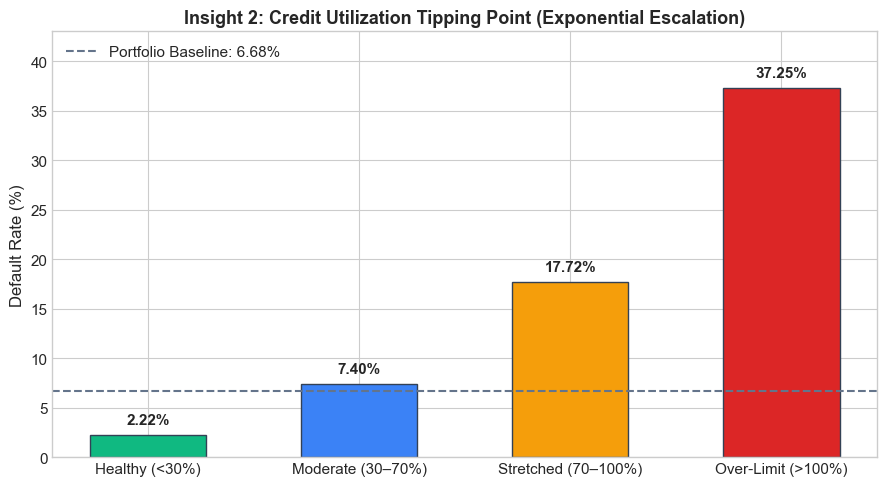

,util_tier,Total_Borrowers,Defaulted_Count,Default_Rate,Default_Rate_Pct
0,Healthy (<30%),92882,2061,0.022189,2.22
1,Moderate (30–70%),27170,2011,0.074015,7.40
2,Stretched (70–100%),26627,4717,0.177151,17.72
3,Over-Limit (>100%),3321,1237,0.372478,37.25


In [6]:
# Cohort 2: Revolving Utilization Tiers
util_bins = [-0.01, 0.30, 0.70, 1.0, np.inf]
util_labels = ['Healthy (<30%)', 'Moderate (30–70%)', 'Stretched (70–100%)', 'Over-Limit (>100%)']
df['util_tier'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'], bins=util_bins, labels=util_labels)

util_summary = df.groupby('util_tier', observed=False)['SeriousDlqin2yrs'].agg(
    Total_Borrowers='count',
    Defaulted_Count='sum',
    Default_Rate='mean'
).reset_index()
util_summary['Default_Rate_Pct'] = (util_summary['Default_Rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    util_summary['util_tier'],
    util_summary['Default_Rate_Pct'],
    color=['#10b981', '#3b82f6', '#f59e0b', '#dc2626'],
    width=0.55,
    edgecolor='#334155'
)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.set_title('Insight 2: Credit Utilization Tipping Point (Exponential Escalation)', fontsize=13)
ax.set_ylim(0, 43)

for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, y + 0.8, f'{y:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(baseline_rate, color='#64748b', linestyle='--', linewidth=1.5, label=f'Portfolio Baseline: {baseline_rate:.2f}%')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()
util_summary


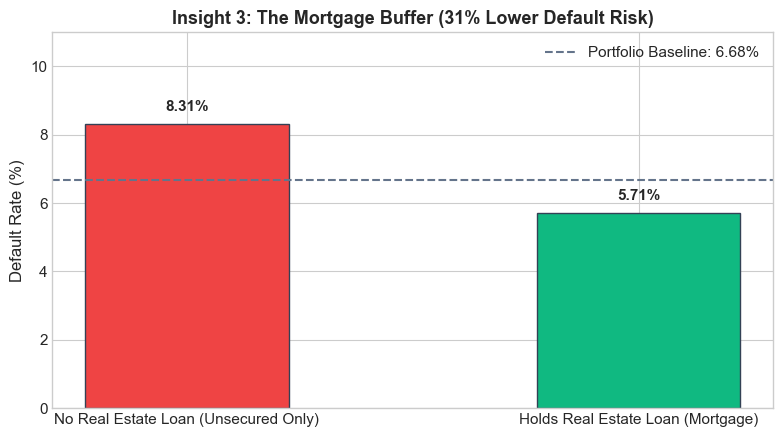

,Category,Total_Borrowers,Defaulted_Count,Default_Rate_Pct
0,No Real Estate Loan (Unsecured Only),56188,4672,8.31
1,Holds Real Estate Loan (Mortgage),93812,5354,5.71


In [7]:
# Cohort 3: Real Estate Collateral Effect
df['has_mortgage'] = df['NumberRealEstateLoansOrLines'] > 0
mortgage_summary = df.groupby('has_mortgage')['SeriousDlqin2yrs'].agg(
    Total_Borrowers='count',
    Defaulted_Count='sum',
    Default_Rate='mean'
).reset_index()
mortgage_summary['Category'] = mortgage_summary['has_mortgage'].map({False: 'No Real Estate Loan (Unsecured Only)', True: 'Holds Real Estate Loan (Mortgage)'})
mortgage_summary['Default_Rate_Pct'] = (mortgage_summary['Default_Rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    mortgage_summary['Category'],
    mortgage_summary['Default_Rate_Pct'],
    color=['#ef4444', '#10b981'],
    width=0.45,
    edgecolor='#334155'
)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.set_title('Insight 3: The Mortgage Buffer (31% Lower Default Risk)', fontsize=13)
ax.set_ylim(0, 11)

for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, y + 0.3, f'{y:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(baseline_rate, color='#64748b', linestyle='--', linewidth=1.5, label=f'Portfolio Baseline: {baseline_rate:.2f}%')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
mortgage_summary[['Category', 'Total_Borrowers', 'Defaulted_Count', 'Default_Rate_Pct']]


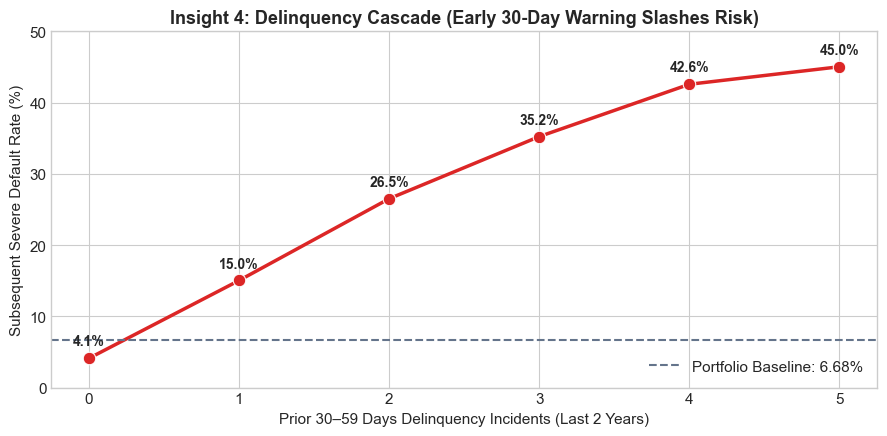

,NumberOfTime30-59DaysPastDueNotWorse,Count,Default_Rate,Default_Rate_Pct
0,0,126287,0.041081,4.11
1,1,16033,0.150253,15.03
2,2,4598,0.265115,26.51
3,3,1754,0.352338,35.23
4,4,747,0.425703,42.57
5,5,342,0.450292,45.03


In [8]:
# Cohort 4: Delinquency Cascades (Early Warning Mechanism)
delinq_summary = df.groupby('NumberOfTime30-59DaysPastDueNotWorse')['SeriousDlqin2yrs'].agg(
    Count='count',
    Default_Rate='mean'
).reset_index().head(6)
delinq_summary['Default_Rate_Pct'] = (delinq_summary['Default_Rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(
    data=delinq_summary,
    x='NumberOfTime30-59DaysPastDueNotWorse',
    y='Default_Rate_Pct',
    marker='o',
    markersize=9,
    color='#dc2626',
    linewidth=2.5,
    ax=ax
)
ax.set_title('Insight 4: Delinquency Cascade (Early 30-Day Warning Slashes Risk)', fontsize=13)
ax.set_xlabel('Prior 30–59 Days Delinquency Incidents (Last 2 Years)', fontsize=11)
ax.set_ylabel('Subsequent Severe Default Rate (%)', fontsize=11)
ax.set_ylim(0, 50)

for _, row in delinq_summary.iterrows():
    ax.text(row['NumberOfTime30-59DaysPastDueNotWorse'], row['Default_Rate_Pct'] + 1.8,
            f"{row['Default_Rate_Pct']:.1f}%", ha='center', fontweight='bold', fontsize=10)

ax.axhline(baseline_rate, color='#64748b', linestyle='--', linewidth=1.5, label=f'Portfolio Baseline: {baseline_rate:.2f}%')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()
delinq_summary


---
## 6. 💼 Synthesis: 4 Core Business Insights & Underwriting Policy Matrix

Based on our empirical cohort analysis across 150,000 retail borrowers, we translate our statistical findings into bank underwriting policies:

| No | Business Insight | Empirical Finding | Actionable Underwriting Policy |
| :--- | :--- | :--- | :--- |
| **1** | **The Age & Asset Accumulation Gap** | Borrowers aged <30 exhibit an **11.73% default rate**, compared to just **3.10% for seniors (60+)** — a **3.8x risk multiplier**. | Implement graduated credit limits for younger borrowers with lower initial lines, increasing limits only upon demonstrated 12-month clean repayment track record. |
| **2** | **The 70% Credit Utilization Tipping Point** | Default rates remain benign at **2.22%** when utilization is <30%, but jump to **17.72%** at 70–100%, and skyrocket to **37.25%** for over-limit borrowers. | Trigger automated SMS/Email risk warnings and freeze temporary credit line increases whenever revolving utilization crosses the 70% threshold. |
| **3** | **The Mortgage Collateral Buffer** | Borrowers holding at least one real estate loan have a **5.71% default rate**, versus **8.31% for uncollateralized borrowers** (a **31% risk reduction**). | Factor asset-backing into risk-adjusted pricing: Offer preferential interest rates (50–100 bps discount) to applicants holding verified real estate assets. |
| **4** | **The 30-Day Early Warning Cascade** | Even a single prior 30–59 day delinquency incident surges subsequent 2-year default probability from **4.1% to 15.0%** (~3.7x surge, escalating to 26.5% at 2 incidents). | Treat 30-day delinquency as a high-priority early warning indicator in proactive debt collection and automated credit card line reduction. |


---
## 🎯 Day 2 Milestone Complete!
- ✅ **Univariate Distributions Explored**: Visualized distributions of age, income, debt ratio, and credit lines.
- ✅ **Correlation Structure Mapped**: Identified delinquency features and revolving utilization as top predictive signals.
- ✅ **Risk Cohorts Dissected**: Quantified default rates across age brackets, utilization tiers, collateral status, and delinquency cascades.
- ✅ **Actionable Credit Policies Formulated**: Synthesized findings into executive underwriting rules.
- ⏭️ **Next Step (Day 3)**: Supervised Machine Learning Modeling (Baseline Logistic Regression vs Tuned XGBoost), handling severe class imbalance, and applying **SHAP (SHapley Additive exPlanations)** for regulatory transparency.
